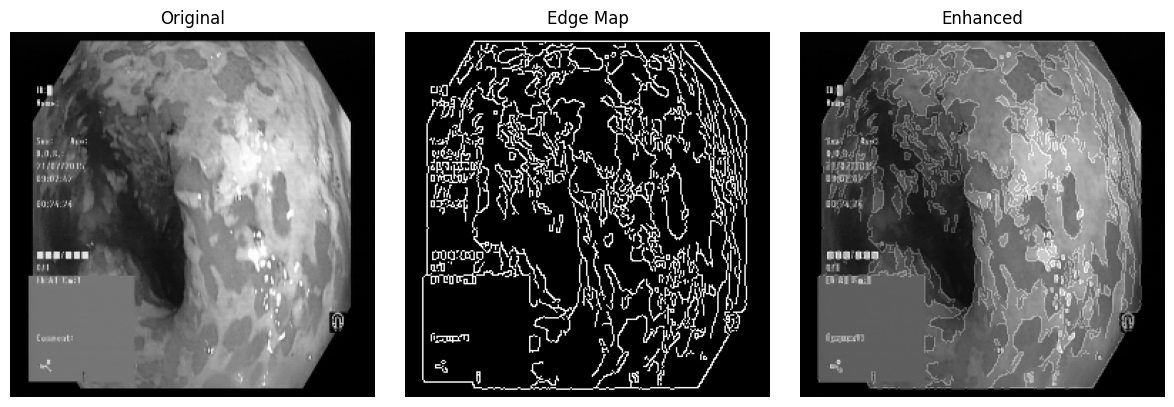

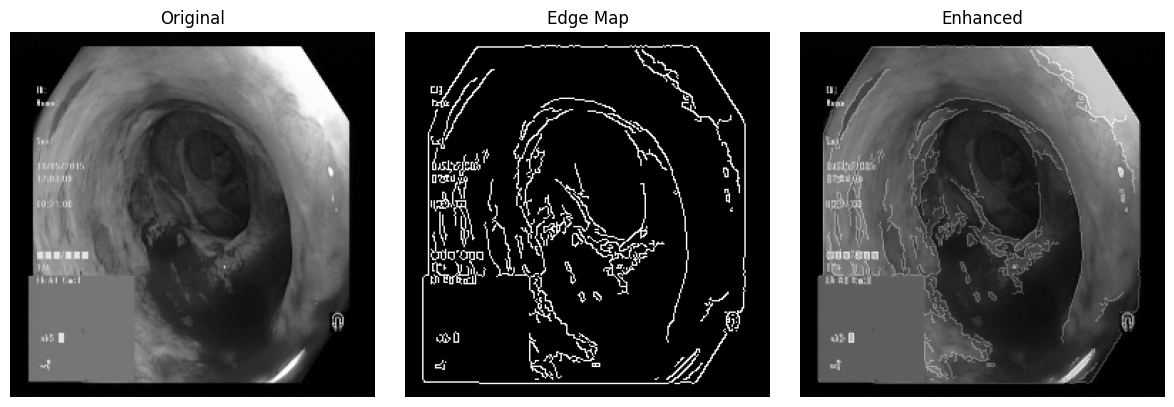

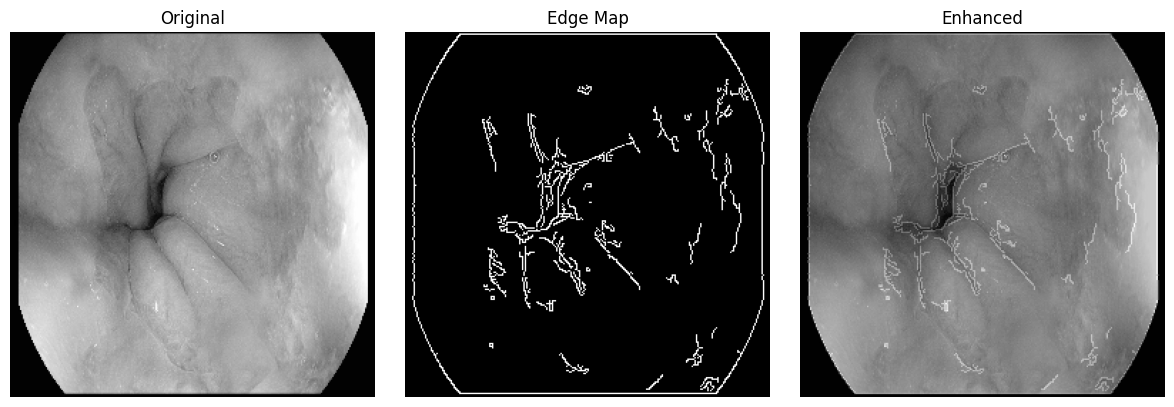

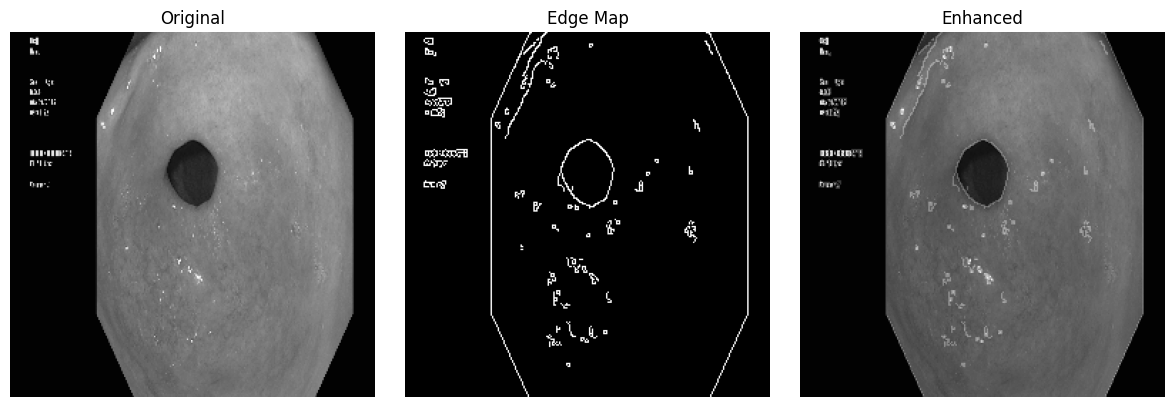

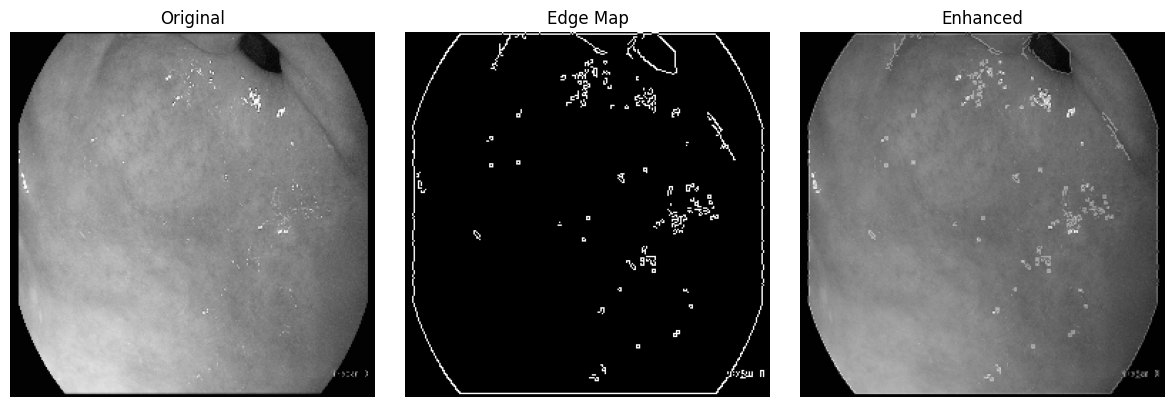

In [21]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def load_and_resize(image_path, size=(256, 256)):
    """Load an image, convert to grayscale, and resize it."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image not found at {image_path}")
    img = cv2.resize(img, size)
    return img

def extract_edges(img, low_threshold=50, high_threshold=150):
    """Extract edges using Canny edge detection."""
    edges = cv2.Canny(img, low_threshold, high_threshold)
    return edges

def blend_images(original, edges, alpha=0.8, beta=0.2):
    """
    Blend the original image with the edge map.
    The parameters alpha and beta determine the blending weights.
    """
    # Since both images are in grayscale and same size, we can blend directly.
    blended = cv2.addWeighted(original, alpha, edges, beta, 0)
    return blended

def process_image(image_path, output_dir, size=(256, 256)):
    """
    Process a single image: load, resize, extract edges, blend,
    and save the original, edge map, and enhanced image.
    """
    # Load and resize the image
    original = load_and_resize(image_path, size)
    
    # Extract edges
    edges = extract_edges(original)
    
    # Blend original and edge map
    enhanced = blend_images(original, edges)
    
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Define filenames for saving
    base_name = os.path.basename(image_path)
    orig_filename = os.path.join(output_dir, f"original_{base_name}")
    edges_filename = os.path.join(output_dir, f"edges_{base_name}")
    enhanced_filename = os.path.join(output_dir, f"enhanced_{base_name}")
    
    # Save the images
    cv2.imwrite(orig_filename, original)
    cv2.imwrite(edges_filename, edges)
    cv2.imwrite(enhanced_filename, enhanced)
    
    return original, edges, enhanced

def visualize_results(original, edges, enhanced):
    """Display original, edge map, and enhanced image side-by-side."""
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edge Map")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(enhanced, cmap='gray')
    plt.title("Enhanced")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Example usage:
if __name__ == "__main__":
    # Define input folder containing images and output folder for processed data
    input_folder = "/kaggle/input/endoscopygoodimages/Original"
    output_folder = "/kaggle/working/processed_data"
    
    # Get a list of images (you can adjust the extension filter as needed)
    image_paths = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    # Process a few sample images (let's do 5 samples for visualization)
    samples_to_show = 5
    for i, img_path in enumerate(image_paths[:samples_to_show]):
        orig, edge_map, enhanced = process_image(img_path, output_folder)
        visualize_results(orig, edge_map, enhanced)


Epoch [1/1000], Loss: 0.5933
Epoch [2/1000], Loss: 0.5917
Epoch [3/1000], Loss: 0.5900
Epoch [4/1000], Loss: 0.5876
Epoch [5/1000], Loss: 0.5842
Epoch [6/1000], Loss: 0.5777
Epoch [7/1000], Loss: 0.5680
Epoch [8/1000], Loss: 0.5581
Epoch [9/1000], Loss: 0.5544
Epoch [10/1000], Loss: 0.5508
Epoch [11/1000], Loss: 0.5448
Epoch [12/1000], Loss: 0.5395
Epoch [13/1000], Loss: 0.5368
Epoch [14/1000], Loss: 0.5351
Epoch [15/1000], Loss: 0.5329
Epoch [16/1000], Loss: 0.5300
Epoch [17/1000], Loss: 0.5266
Epoch [18/1000], Loss: 0.5231
Epoch [19/1000], Loss: 0.5186
Epoch [20/1000], Loss: 0.5139
Epoch [21/1000], Loss: 0.5076
Epoch [22/1000], Loss: 0.4994
Epoch [23/1000], Loss: 0.4901
Epoch [24/1000], Loss: 0.4755
Epoch [25/1000], Loss: 0.4551
Epoch [26/1000], Loss: 0.4285
Epoch [27/1000], Loss: 0.3924
Epoch [28/1000], Loss: 0.3564
Epoch [29/1000], Loss: 0.3349
Epoch [30/1000], Loss: 0.3410
Epoch [31/1000], Loss: 0.3467
Epoch [32/1000], Loss: 0.3384
Epoch [33/1000], Loss: 0.3266
Epoch [34/1000], Lo

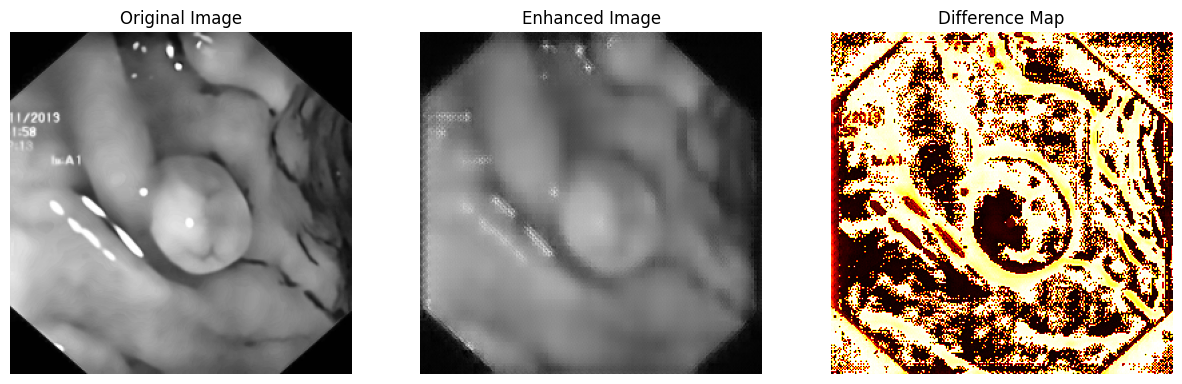

PSNR: 24.83 dB, SSIM: 0.7940


In [27]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.models import vgg16
from skimage.metrics import peak_signal_noise_ratio as psnr_metric, structural_similarity as ssim_metric

# -----------------------------
# Part 2.1: Custom Dataset Loader
# -----------------------------
class ProcessedImagesDataset(Dataset):
    """
    Dataset that loads preprocessed (edge-enhanced) images.
    Here, we assume the preprocessed images are stored in 'processed_data'
    and are grayscale images.
    """
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
                            if f.lower().endswith(('.jpg', '.png', '.jpeg')) and 'enhanced' in f]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        # Load in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Failed to load image at {img_path}")
        # Normalize and convert to tensor
        img = cv2.resize(img, (256, 256))
        img = img / 255.0
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        # For an autoencoder, input and target are the same
        return img, img

# -----------------------------
# Part 2.2: UNet Autoencoder Model
# -----------------------------
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        # Encoder: downsampling
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        # Decoder: upsampling
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(inplace=True)
        )
        # Final convolution to bring back to 1 channel output
        self.final = nn.Conv2d(64, 1, kernel_size=1)
    
    def forward(self, x):
        enc = self.encoder(x)
        bottleneck = self.bottleneck(enc)
        dec = self.decoder(bottleneck)
        out = self.final(dec)
        return out

# -----------------------------
# Part 2.3: Perceptual Loss using VGG (Optional but recommended)
# -----------------------------
class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        # Use the first few layers of VGG16 to capture perceptual features
        vgg = vgg16(pretrained=True).features[:8]
        self.vgg = vgg.eval()
        for param in self.vgg.parameters():
            param.requires_grad = False
    
    def forward(self, pred, target):
        # Since VGG expects 3 channels, replicate the grayscale image three times
        pred_3c = pred.repeat(1, 3, 1, 1)
        target_3c = target.repeat(1, 3, 1, 1)
        pred_features = self.vgg(pred_3c)
        target_features = self.vgg(target_3c)
        loss = torch.mean((pred_features - target_features) ** 2)
        return loss

# -----------------------------
# Part 2.4: Training Loop Setup
# -----------------------------
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize dataset and dataloader
dataset_dir = "processed_data"  # Folder where processed enhanced images are saved
dataset = ProcessedImagesDataset(dataset_dir)
data_loader = DataLoader(dataset, batch_size=4, shuffle=True)

# Initialize model, loss functions, and optimizer
model = UNet().to(device)
criterion_mse = nn.MSELoss()
criterion_perceptual = PerceptualLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Number of epochs for training (adjust as needed)
num_epochs = 1000

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for inputs, targets in data_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss_mse = criterion_mse(outputs, targets)
        loss_perc = criterion_perceptual(outputs, targets)
        # Combine losses; adjust the weight of perceptual loss as needed
        loss = loss_mse + 0.1 * loss_perc
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * inputs.size(0)
    
    avg_loss = epoch_loss / len(dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Save the trained model
torch.save(model.state_dict(), "enhancement_model.pth")
print("Model saved successfully!")

# -----------------------------
# Part 2.5: Evaluation on Test Images
# -----------------------------
def evaluate_model(model, image_path):
    model.eval()
    # Load test image (assuming grayscale and resized to 256x256)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    img_norm = img / 255.0
    img_tensor = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output_tensor = model(img_tensor)
    output_img = output_tensor.squeeze().cpu().numpy() * 255.0
    output_img = np.clip(output_img, 0, 255).astype(np.uint8)
    
    # Compute PSNR and SSIM
    psnr_val = psnr_metric(img, output_img, data_range=255)
    ssim_val = ssim_metric(img, output_img, data_range=255)
    
    # Visualize the results
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img, cmap='gray'); axs[0].set_title("Original Image"); axs[0].axis('off')
    axs[1].imshow(output_img, cmap='gray'); axs[1].set_title("Enhanced Image"); axs[1].axis('off')
    axs[2].imshow(np.abs(img - output_img), cmap='hot'); axs[2].set_title("Difference Map"); axs[2].axis('off')
    plt.show()
    
    return psnr_val, ssim_val

# Example evaluation
test_image_path = "/kaggle/input/preprocessed2/PreProcessed1/processed_image_10.jpg"  # Replace with an actual test image path
psnr_score, ssim_score = evaluate_model(model, test_image_path)
print(f"PSNR: {psnr_score:.2f} dB, SSIM: {ssim_score:.4f}")


In [23]:
test_image_path

'/kaggle/input/endoscopygoodimages/Original/0000558.jpg'